# Netflix Exploratory Data Analysis 

## Objective
The goal of this project is to analyze Netflix's content library to understand:
- Distribution of Movies and TV Shows on Netflix
- Growth over the years
- Country-wise distribution
- Genre popularity
- Rating distribution
- Director analysis

## Dataset
Source: Kaggle - Netflix Movies and TV Shows

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- JupyterLab

## Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')

In [3]:
df = pd.read_csv('netflix_titles.csv.zip')

In [22]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [23]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [24]:
df.shape

(8807, 12)

## Data Exploration

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [9]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [26]:
df['month_added'] = df['date_added'].str.strip().str.split().str.get(0)
df['year_added'] = df['date_added'].str.strip().str.split().str.get(2)

In [27]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,2021


### Converting to datetime
- The date_added column was converted to datetime format to enable time-based analysis and visualization.

In [28]:
df['date_added'] = df['date_added'].str.strip()

## Exploratory Data Analysis

### 1. Distribution of Movies vs TV Shows

In [33]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [34]:
temp1 = df.groupby('type').count()
temp1

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
type,,,,,,,,,,,,,
Movie,6131,6131,5943,5656,5691,6131,6131,6129,6128,6131,6131,6131,6131
TV Show,2676,2676,230,2326,2285,2666,2676,2674,2676,2676,2676,2666,2666


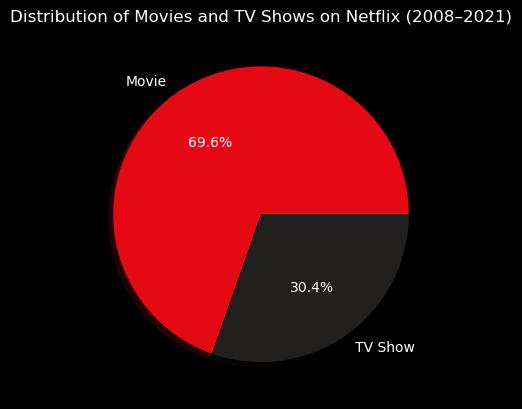

In [38]:
plt.pie(temp1['show_id'],labels=temp1.index,autopct='%0.1f%%',colors=['#E50914','#221F1F'],shadow=True)
plt.title('Distribution of Movies and TV Shows on Netflix (2008–2021)')
plt.show()

- Observation
    - Movies account 69.6% of Netflix content
    - TV Shows account 30.4% of Netflix content

- Insight
    - Netflix's catalog is dominated by movies, indicating a stronger focus on film content than serialized TV programming.

### 2. Countries with most content on Netflix

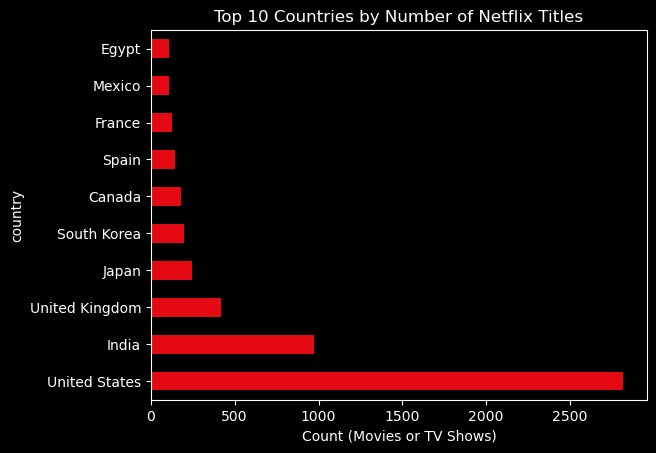

In [39]:
temp = df['country'].value_counts().head(10).plot(kind='barh',color='#E50914')
plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Count (Movies or TV Shows)')
plt.show()

- Observation
    - United States have most number of content on Netflix (2500+).
    - India is on 2nd postion with approx. 1000 movies/tv shows
- Insight
    - United States dominate on Netflix, as it is US Company

### 3. Content Added over the years 

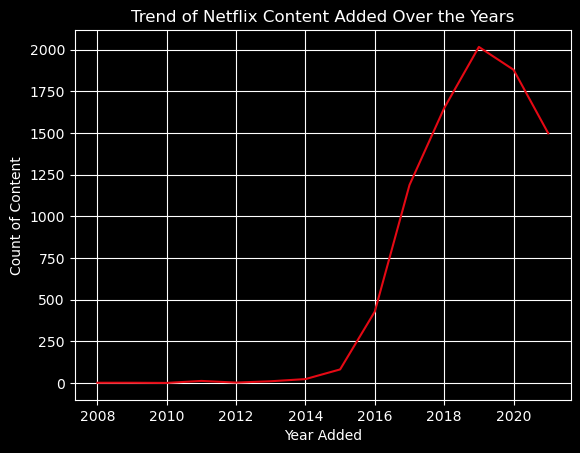

In [63]:
year_df = df['year_added'].value_counts()
year_df.sort_index(ascending=True).plot(kind='line',color='#E50914',xlabel='Year Added',ylabel='Count of Content',title='Trend of Netflix Content Added Over the Years')
plt.grid()
plt.show()

- Observation
    - This plot shows content uploded on Netflix from 2008-2021.
    - Content addition increased rapidly between 2016-2018.
    - The highest number of titles was added in 2019.
    - Additions declined slightly after 2019.

- Insight
    - Netflix aggressively expanded its library during 2016–2019, likely supporting global growth and investment in original content.

### 4. Rating Distribution

In [43]:
r = df[~df['rating'].str.endswith('min',na=False)]
r

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",November,2019
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",July,2019
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,November,2019
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",January,2020


In [44]:
rating_df = r['rating'].value_counts().reset_index()

In [45]:
rating_df

,rating,count
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


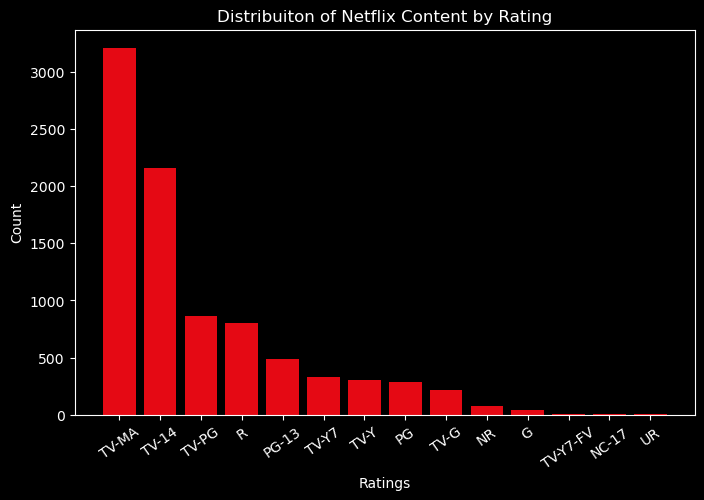

In [52]:
plt.figure(figsize=(8,5))
plt.bar(rating_df['rating'],rating_df['count'],color='#E50914')
plt.title('Distribuiton of Netflix Content by Rating')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.xticks(rotation=35)
plt.show()

- Observation
    - TV-MA is the most common rating.
    - TV-14 is the second most common rating.
    - UR and NC-17 titles are rare.

- Insight
    - Netflix primarily targets mature and teenage audiences rather than young children.

### 5. Movie Duration Distribution

In [53]:
duration_df = df[df['duration'].str.endswith('min')]
duration_df['duration'] = duration_df['duration'].str.strip().str.split().str.get(0).astype(int)
duration_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm...",September,2021
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,September,2021
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",September,2021
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...,September,2021
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...,September,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,March,2016
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",November,2019
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,November,2019
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",January,2020


<Figure size 1000x800 with 0 Axes>

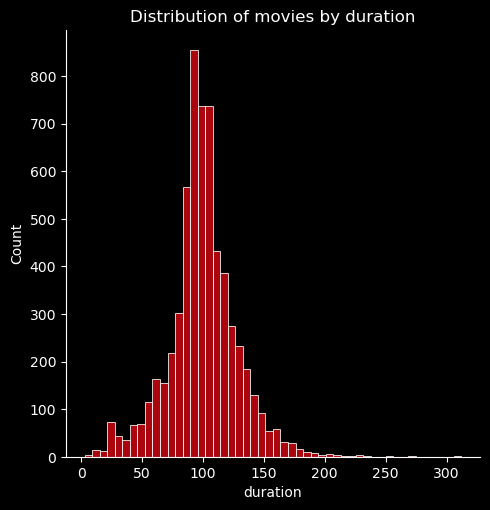

In [62]:
plt.figure(figsize=(10,8))
sns.displot(duration_df,x='duration',kind='hist',bins=50,color='#E50914')
plt.title('Distribution of movies by duration')
plt.show()

- Observation
    - Most movies are between 80 and 120 minutes.
    - The peak occurs around 90–100 minutes.
     
- Insight
    - Netflix movies generally follow standard feature-film lengths, suggesting audience preference for moderate-duration content.

### 6. Genres Distribution

In [5]:
geners = (df['listed_in'].str.split(',').explode().str.strip())
top_geners = geners.value_counts().head(10)
top_geners=top_geners.reset_index()
top_geners

,listed_in,count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


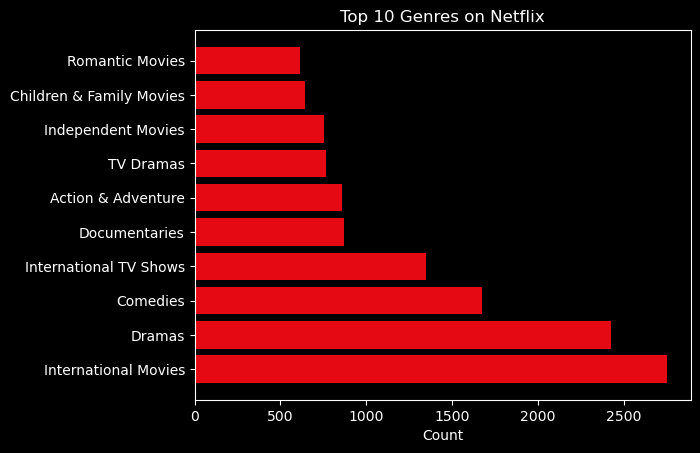

In [6]:
plt.barh(top_geners['listed_in'],top_geners['count'],color='#E50914')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.show()

- Observation
    - 'International Movies' genre is the most famous gen as the number of content is the highest (ie.2500+).
    - The second most famous genre is 'Dramas'.

- Insight
    - Netflix is a global brand and that's why the most famous genres are related to International content.

### 7. Country-wise Distribution of Movies and TV Shows on Netflix

In [64]:
country_df = df.copy()
country_df['country'].str.split(',')
country_df = country_df.explode('country')
country_df['country'] = country_df['country'].str.strip()
country_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",November,2019
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",July,2019
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,November,2019
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",January,2020


In [65]:
top_country = country_df['country'].value_counts().head(10).index
top_country

Index(['United States', 'India', 'United Kingdom', 'Japan', 'South Korea',
       'Canada', 'Spain', 'France', 'Mexico', 'Egypt'],
      dtype='str', name='country')

In [66]:
country_type = pd.crosstab(country_df['country'], country_df['type'])
country_type

type,Movie,TV Show
country,,
", France, Algeria",1,0
", South Korea",0,1
Argentina,38,18
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",2,0
...,...,...
Venezuela,1,0
"Venezuela, Colombia",1,0
Vietnam,7,0


In [68]:
country_type = country_type.loc[top_country]
country_type

type,Movie,TV Show
country,,
United States,2058,760
India,893,79
United Kingdom,206,213
Japan,76,169
South Korea,41,158
Canada,122,59
Spain,97,48
France,75,49
Mexico,70,40


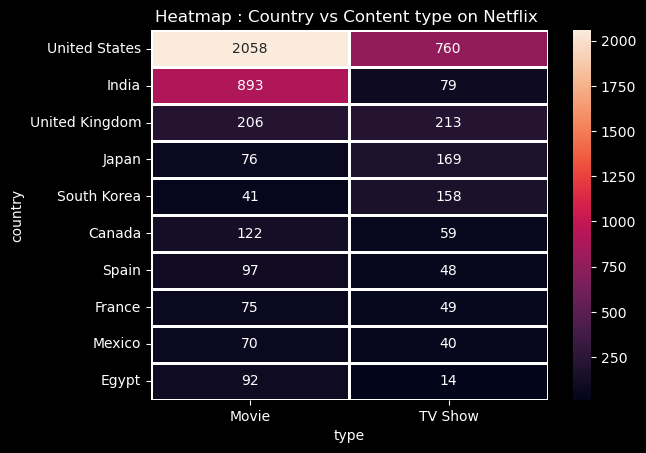

In [71]:
sns.heatmap(country_type,linewidths=2,annot=True,fmt='d')
plt.title('Heatmap : Country vs Content type on Netflix')
plt.show()

- Observation
    - The United States has the highest number of both Movies and TV Shows on Netflix.
    - India contributes a large number of Movies but relatively fewer TV Shows.
    - In most countries, Movies outnumber TV Shows.
    - UK is the only country which has balance between movies and tv shows.
      
- Insight
    - Netflix's content library is heavily driven by movie production across most countries.
    - The dominance of the United States highlights its importance as Netflix's largest content source.

### 8. Distribution of Directors

In [72]:
directors = (
    df['director']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

top_directors = directors.value_counts().head(10)
top_directors

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

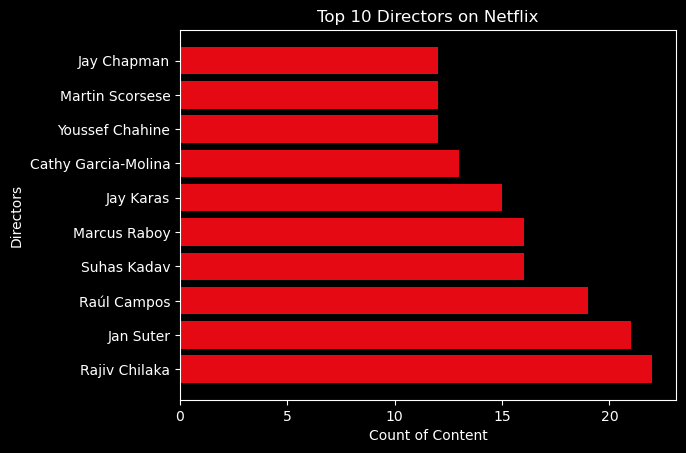

In [73]:
plt.barh(top_directors.index,top_directors.values,color='#E50914')

plt.title('Top 10 Directors on Netflix')
plt.xlabel('Count of Content')
plt.ylabel('Directors')
plt.show()

- Observation
    - Rajiv Chilaka has directed the highest number of titles in the dataset.
    - Raúl Campos and Jan Suter appear among the most frequent directors.
    - The difference between the top directors is relatively small.

- Insights
    - No single director dominates Netflix's catalog.
    - Netflix content is distributed across a wide range of directors, indicating a diverse content acquisition strategy.

# Final Conclusion

This analysis explored Netflix's content library to identify trends in content type, ratings, countries, genres, release years, and directors.

Key findings include:

- Movies dominate Netflix's catalog.
- The United States contributes the largest share of content.
- Netflix expanded rapidly after 2015.
- TV-MA is the most common content rating.
- International Movies are the most common genre.
- Netflix has a diverse range of directors instead of relying on only a few.

Overall, Netflix's library reflects a global content strategy with increasing international expansion.